To switch from **uniform hemisphere scattering** to **true Lambertian scattering** in your Python ray tracer, only one core idea changes:

Before:

$$
\vec{d} = \text{random-on-hemisphere} (N)
$$

After (Lambertian):

$$
\vec{d} = N + \text{random-unit-vector} ()
$$

This creates cosine-weighted scattering.

---

# 1. Concept Difference

| Method             | Formula                             | Meaning                        | Problem                 |
| ------------------ | ----------------------------------- | ------------------------------ | ----------------------- |
| Uniform Hemisphere | $\vec d = random_on_hemisphere(N)$  | Equal chance in all directions | Not physically accurate |
| Lambertian         | $\vec d = N + random_unit_vector()$ | More rays near normal          | Realistic diffuse       |

---

# 2. Why Lambertian Works

Real diffuse surfaces follow:

$$
P(\phi) \propto \cos(\phi)
$$

Where:

* $\phi$ = angle between outgoing ray and surface normal
* More probability when $\phi$ is small

Meaning:

If ray is close to normal:

$$
\cos(0)=1
$$

Maximum probability.

If ray is sideways:

$$
\cos(90^\circ)=0
$$

Minimum probability.

---

# 3. Geometry

At hit point $P$:

Surface normal:

$$
N
$$

Unit sphere center:

$$
P+N
$$

Random point on sphere:

$$
S=(P+N)+R
$$

where:

$$
|R|=1
$$

Scatter direction:

$$
D=S-P
$$

Substitute:

$$
D=(P+N+R)-P
$$

Simplifies:

$$
D=N+R
$$

This is exactly Lambertian.

---

# 4. What changes in your code

Old:

```python
direction = random_on_hemisphere(rec.normal)
```

New:

```python
direction = rec.normal + random_unit_vector()
```

---

# 5. Full modified Python code (with learning comments)

```python
def ray_color(self, r, world, depth):

    # ==========================================
    # STEP 1: Stop recursion if bounce limit ends
    #
    # Formula:
    # depth <= 0
    #
    # Purpose:
    # Prevent infinite bouncing
    # ==========================================
    if depth <= 0:
        return Vec3(0, 0, 0)

    rec = HitRecord()

    # ==========================================
    # STEP 2: Check intersection
    #
    # Formula:
    # t ∈ [0.001, ∞)
    #
    # Purpose:
    # Avoid self-intersection (shadow acne)
    # ==========================================
    if world.hit(
        r,
        Interval(0.001, INFINITY),
        rec
    ):

        # ==========================================
        # OLD METHOD (uniform hemisphere)
        #
        # direction = random_on_hemisphere(rec.normal)
        #
        # Problem:
        # Every direction equally likely
        # Not physically accurate
        # ==========================================

        # ==========================================
        # NEW METHOD (Lambertian diffuse)
        #
        # Formula:
        # D = N + R
        #
        # N = surface normal
        # R = random unit vector
        #
        # Purpose:
        # Creates cosine-weighted scattering
        # More rays near normal
        # More realistic diffuse reflection
        # ==========================================
        direction = (
            rec.normal
            + random_unit_vector()
        )

        # ==========================================
        # Safety fix:
        #
        # Sometimes:
        # N + R ≈ 0
        #
        # That creates invalid ray direction.
        #
        # Fix:
        # if near zero, use normal itself
        # ==========================================
        if direction.near_zero():
            direction = rec.normal

        # ==========================================
        # Create scattered ray
        #
        # Formula:
        # Ray(P, D)
        #
        # P = hit point
        # D = Lambertian direction
        # ==========================================
        scattered_ray = Ray(
            rec.p,
            direction
        )

        # ==========================================
        # Recursive light bounce
        #
        # Formula:
        #
        # L = 0.5 × next_bounce
        #
        # Purpose:
        # Energy loss after each bounce
        # ==========================================
        return 0.5 * self.ray_color(
            scattered_ray,
            world,
            depth - 1
        )

    # ==========================================
    # STEP 3: Background color
    #
    # Formula:
    # t = 0.5(y + 1)
    #
    # Purpose:
    # Convert y from [-1,1] to [0,1]
    # ==========================================
    unit_dir = unit_vector(
        r.direction()
    )

    t = 0.5 * (
        unit_dir.y + 1.0
    )

    # ==========================================
    # Linear interpolation
    #
    # Formula:
    #
    # C = (1-t)A + tB
    #
    # A = white
    # B = blue
    #
    # Purpose:
    # Sky gradient
    # ==========================================
    return (
        (1.0 - t) * Vec3(1, 1, 1)
        + t * Vec3(0.5, 0.7, 1.0)
    )
```

---

# 6. You need this helper function

Inside your `vec3.py`:

```python
import random
import math


def random_unit_vector():

    while True:

        p = Vec3(
            random.uniform(-1, 1),
            random.uniform(-1, 1),
            random.uniform(-1, 1)
        )

        # Reject if outside sphere
        if p.length_squared() >= 1:
            continue

        # Normalize
        return unit_vector(p)
```

---

# 7. Why image changes visually

| Effect         | Why                            |
| -------------- | ------------------------------ |
| Darker shadows | More rays go upward            |
| More blue tint | Sky light bounces into objects |
| Better realism | Cosine distribution            |

---

# 8. Mathematical summary

Diffuse reflection integral:

$$
L_o=\int_\Omega L_i \cos(\phi)d\omega
$$

Where:

| Symbol    | Meaning         |
| --------- | --------------- |
| $L_o$     | outgoing light  |
| $L_i$     | incoming light  |
| $\Omega$  | hemisphere      |
| $\phi$    | angle to normal |
| $d\omega$ | solid angle     |

Lambertian approximates this using random sampling.

Your new code now follows this physically based model.


# Code - Camera True Lambertian_reflection

In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [2]:
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_unit_vector   # NEW: Lambertian uses this
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor
import random


class Camera:

    def __init__(self):

        # ==========================================
        # Image settings
        # ==========================================

        # Width / height ratio
        self.aspect_ratio = 16 / 9

        # Horizontal resolution
        self.image_width = 400

        # Number of random samples per pixel
        # More samples = less noise
        self.samples_per_pixel = 100

        # Maximum recursive ray bounces
        self.max_depth = 50

    def initialize(self):

        # ==========================================
        # Compute image height
        #
        # Formula:
        # H = W / aspect_ratio
        # ==========================================
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        # Safety minimum
        if self.image_height < 1:
            self.image_height = 1

        # ==========================================
        # Pixel averaging scale
        #
        # Formula:
        # final = total / samples
        # ==========================================
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # ==========================================
        # Camera center
        # ==========================================
        self.center = Vec3(0, 0, 0)

        # Distance from camera to viewport
        focal_length = 1.0

        # Viewport physical height
        viewport_height = 2.0

        # Keep aspect ratio
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # ==========================================
        # Viewport basis vectors
        # ==========================================

        # Horizontal vector
        viewport_u = Vec3(
            viewport_width, 0, 0
        )

        # Vertical vector (negative y = top-down image)
        viewport_v = Vec3(
            0, -viewport_height, 0
        )

        # ==========================================
        # Pixel step size
        # ==========================================
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # ==========================================
        # Upper-left viewport corner
        #
        # Formula:
        # center - focal - u/2 - v/2
        # ==========================================
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u
                + self.pixel_delta_v
            )
        )

    def sample_square(self):

        # ==========================================
        # Random subpixel sampling
        #
        # Range:
        # [-0.5, +0.5]
        #
        # Purpose:
        # Anti-aliasing
        # ==========================================
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):

        # Random offset inside pixel
        offset = self.sample_square()

        # Random sample position
        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # Ray direction
        ray_direction = (
            pixel_sample - self.center
        )

        return Ray(
            self.center,
            ray_direction
        )

    def ray_color(self, r, world, depth):

        # ==========================================
        # Stop recursion
        # ==========================================
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ==========================================
        # Hit test with epsilon fix
        #
        # Avoid shadow acne
        # ==========================================
        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):

            # ==========================================
            # Lambertian scattering
            #
            # Formula:
            #
            # D = N + R
            #
            # N = surface normal
            # R = random unit vector
            #
            # Creates cosine-weighted diffuse reflection
            # ==========================================
            direction = (
                rec.normal
                + random_unit_vector()
            )

            # Prevent near-zero direction
            if direction.near_zero():
                direction = rec.normal

            # ==========================================
            # Shadow acne origin shift
            #
            # Formula:
            # P' = P + εN
            # ==========================================
            epsilon = 0.001

            scattered_origin = (
                rec.p
                + epsilon * rec.normal
            )

            # Create bounced ray
            scattered_ray = Ray(
                scattered_origin,
                direction
            )

            # Recursive bounce with energy loss
            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        # ==========================================
        # Background gradient
        # ==========================================

        unit_dir = unit_vector(
            r.direction()
        )

        # Convert y into blend factor
        t = 0.5 * (
            unit_dir.y + 1.0
        )

        # Linear interpolation
        #
        # white -> blue
        return (
            (1.0 - t)
            * Vec3(1, 1, 1)
            + t
            * Vec3(0.5, 0.7, 1.0)
        )

    def render(self, world):

        # Setup camera
        self.initialize()

        with open("output.ppm", "w") as f:

            # ==========================================
            # PPM header
            # ==========================================
            f.write(
                f"P3\n"
                f"{self.image_width} "
                f"{self.image_height}\n"
                f"255\n"
            )

            # Render rows
            pbar = tqdm(range(self.image_height))

            for j in pbar:

                # Update stats every 5 rows
                if j % 5 == 0:
                    stats = system_monitor()
                    pbar.set_postfix(stats)

                for i in range(self.image_width):

                    # Start black
                    pixel_color = Vec3(0, 0, 0)

                    # Multi-sampling loop
                    for _ in range(
                        self.samples_per_pixel
                    ):

                        # Shoot ray
                        r = self.get_ray(i, j)

                        # Gather color
                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    # Average samples
                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    # Convert float -> integer
                    ir = int(
                        255.999 * pixel_color.x
                    )

                    ig = int(
                        255.999 * pixel_color.y
                    )

                    ib = int(
                        255.999 * pixel_color.z
                    )

                    # Write pixel
                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):

        # Open rendered result
        return image_viewer("output.ppm")

In [7]:
from util.sphere import Sphere
#from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [04:03<00:00,  1.08s/it, CPU=37.6%, RAM=73.0%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=653.0MB]


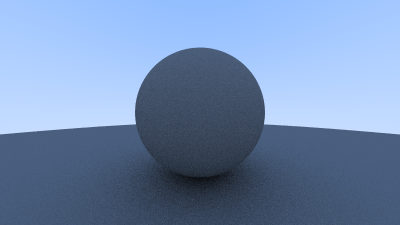

In [8]:
cam.show()

# Code Reduce

In [9]:
from util.sphere import Sphere
from util.camera_diff4_lambertain_reflection import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:57<00:00,  1.06s/it, CPU=61.0%, RAM=75.1%, CPU Temp=N/A, GPU Temp=53.0°C, VRAM=650.0MB]


In [ ]:
cam.show()